# Section 1 — Foundations and Traditional Machine Learning

Linear regression, logistic regression, decision trees, and k-means — fit, evaluate, and interpret on two real-world insurance datasets.

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger (8–9 June 2026, Munich).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/ml-genai-actuarial-practice/blob/main/notebooks/01_foundations_traditional_ml/01_foundations_traditional_ml.ipynb)

Repository: [simonhatzesberger/ml-genai-actuarial-practice](https://github.com/simonhatzesberger/ml-genai-actuarial-practice) — Code under the [MIT License](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).


In the next sixty minutes we train the four classical methods from the slides on two real-world insurance datasets:

- **Regression** uses a US **medical-cost** dataset (1,338 policyholders; target is the annual medical insurance charge in USD).
- **Classification** and **unsupervised clustering** use a **car-insurance** dataset (10,000 drivers; target is whether the policyholder filed a claim).

Both datasets are available on Kaggle; copies sit in this notebook's `data/` folder. We fit each model, visualise the decisions where possible (tree plots, sigmoid curves, dendrogram-style centroid heatmaps), and interpret the results in plain actuarial language at every step.


## Contents

- [Learning objectives](#learning-objectives)
- [Setup](#setup)
- [1. Regression — predicting medical insurance charges](#1-regression-predicting-medical-insurance-charges)
- [2. Binary classification — predicting car-insurance claims](#2-binary-classification-predicting-car-insurance-claims)
- [3. Unsupervised — k-means on the car-insurance portfolio](#3-unsupervised-k-means-on-the-car-insurance-portfolio)
- [Exercises](#exercises)
- [Summary](#summary)
- [Next steps](#next-steps)
- [References](#references)


## Learning objectives

By the end of this notebook you will be able to:

- distinguish supervised from unsupervised learning and pick the right framing for an actuarial question;
- recognise the three faces of supervised learning — regression, binary classification, multiclass — and pick a suitable error metric for each;
- fit and interpret a linear regression, a logistic regression, and a decision tree on tabular insurance data;
- read a **decision-tree diagram** — turn an if-then partition into a portfolio narrative;
- read a bias-variance curve and identify the sweet-spot complexity;
- explain why a decision tree miscalibrates probabilities even when its ranking looks fine;
- run k-means with a sensible choice of K and translate centroids back into actuarial language.


## Setup

The cell below detects whether you are on Google Colab. On Colab it installs the section's pinned dependencies and downloads the two datasets used throughout the notebook. Locally, it assumes you have run `pip install -r notebooks/01_foundations_traditional_ml/requirements.txt` and that `data/data_medical_cost.csv` and `data/data_car_insurance.csv` sit next to this notebook.


In [1]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q -r https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/01_foundations_traditional_ml/requirements.txt
    !mkdir -p data
    !wget -q -O data/data_medical_cost.csv  https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/01_foundations_traditional_ml/data/data_medical_cost.csv
    !wget -q -O data/data_car_insurance.csv https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/01_foundations_traditional_ml/data/data_car_insurance.csv

SEED = 42

print(f"Setup complete. Environment: {'Colab' if IN_COLAB else 'local'}.")


Setup complete. Environment: local.


A small palette and seaborn theme so every figure speaks the same colour language as the slides.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PRIMARY      = "#1F3A6E"
ACCENT_RED   = "#C0504D"
ACCENT_GREEN = "#4E7C59"
GRAY_TEXT    = "#404040"

sns.set_theme(
    style="whitegrid",
    palette=[PRIMARY, ACCENT_RED, ACCENT_GREEN, "#7A8DA8", "#9C7A7A"],
    rc={
        "axes.edgecolor":   GRAY_TEXT,
        "axes.labelcolor":  GRAY_TEXT,
        "xtick.color":      GRAY_TEXT,
        "ytick.color":      GRAY_TEXT,
        "axes.titlecolor":  PRIMARY,
        "axes.titleweight": "bold",
        "grid.color":       "#E5E5E5",
        "figure.facecolor": "white",
        "axes.facecolor":   "white",
    },
)

np.random.seed(SEED)


## 1. Regression — predicting medical insurance charges

Our first task is a regression: predict the **annual medical insurance charge** for a US policyholder from six personal characteristics. This is slide 14's setting — a linear model is the strong, interpretable baseline; a decision tree relaxes the linearity assumption.

> **Dataset.** *Medical Cost Personal Datasets* by Choi (2018), hosted on Kaggle ([mirichoi0218/insurance](https://www.kaggle.com/datasets/mirichoi0218/insurance/data)). 1,338 individuals with seven columns: `age`, `sex`, `bmi`, `children`, `smoker`, `region`, and the target `charges` (USD).


In [3]:
df = pd.read_csv("data/data_medical_cost.csv")
print(f"shape: {df.shape}")
df.head()


shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**A quick read.** Six features, one target (`charges`). Three columns are categorical (`sex`, `smoker`, `region`); the rest are numeric. `charges` is the per-year insurance cost — what an underwriter would want to predict from a new applicant's intake form.


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


**Reading the summary.**

- `charges` ranges from \~\$1.1k to over \$63k. The mean (\~\$13.3k) sits well above the median (\~\$9.4k), so the target is right-skewed.
- `age` covers 18–64, evenly spread.
- `bmi` averages 30.7 — the sample skews unhealthy by US clinical standards.
- About 20 % of the sample are smokers; this single binary feature will turn out to dominate the model.


### Three quick EDA pictures

The target distribution, charges by smoker status, and a Spearman correlation heatmap. The point is to *see the problem*, not exhaust the data.


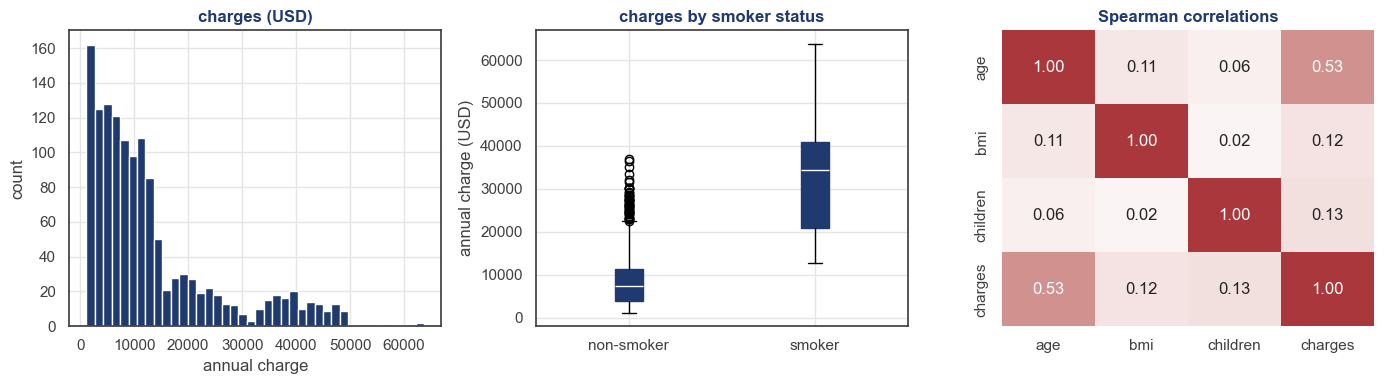

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df["charges"], bins=40, color=PRIMARY, edgecolor="white")
axes[0].set_title("charges (USD)")
axes[0].set_xlabel("annual charge")
axes[0].set_ylabel("count")

axes[1].boxplot(
    [df.loc[df["smoker"] == "no",  "charges"],
     df.loc[df["smoker"] == "yes", "charges"]],
    tick_labels=["non-smoker", "smoker"],
    patch_artist=True,
    boxprops=dict(facecolor=PRIMARY, color=PRIMARY),
    medianprops=dict(color="white"),
)
axes[1].set_title("charges by smoker status")
axes[1].set_ylabel("annual charge (USD)")

num_cols = ["age", "bmi", "children", "charges"]
sns.heatmap(df[num_cols].corr(method="spearman"),
            annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, ax=axes[2], cbar=False)
axes[2].set_title("Spearman correlations")

fig.tight_layout()
plt.show()


**What the EDA tells us.**

- The target distribution is **bimodal**: a tall mode near \$5k and a thin shoulder past \$30k. A plain linear model will struggle to capture both modes without a non-linear feature.
- The bimodality is essentially **driven by smoking**. The smoker box plot sits in a completely different range from the non-smoker box. This is the single strongest signal in the dataset.
- Among numeric features, `age` correlates most with `charges` (Spearman ≈ 0.53). `bmi` shows a weaker positive correlation; `children` is nearly orthogonal to cost.


### Train / test split and a tiny metrics helper

Hold out 20 % for the test set and touch it only at the very end. The helper returns RMSE, MAE, and R².

> **Note.** A production-grade workflow would use a validation set (60/20/20) or k-fold cross-validation for hyperparameter selection. We skip that here because we are not tuning anything that would meaningfully change the conclusions.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

target = "charges"
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

def metrics_table(y_true, y_pred, label="model"):
    return pd.DataFrame(
        {
            "RMSE": [np.sqrt(mean_squared_error(y_true, y_pred))],
            "MAE":  [mean_absolute_error(y_true, y_pred)],
            "R²":   [r2_score(y_true, y_pred)],
        },
        index=[label],
    )

print(f"train: {X_train.shape}   test: {X_test.shape}")


train: (1070, 6)   test: (268, 6)


### Model A — Linear regression

Slide 14's model:

$$\hat y = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p,\qquad \hat\beta = \arg\min_{\beta} \sum_{i=1}^{n}(y_i - \hat y_i)^2.$$

The three categorical features are one-hot encoded inside a `Pipeline` so we can pass the raw DataFrame to `.fit()` and `.predict()`.


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

cat_cols = ["sex", "smoker", "region"]
num_cols_reg = ["age", "bmi", "children"]

preprocess = ColumnTransformer([
    ("num", "passthrough",                          num_cols_reg),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

linear = Pipeline([("preprocess", preprocess), ("lr", LinearRegression())])
linear.fit(X_train, y_train)
y_pred_lr = linear.predict(X_test)

metrics_table(y_test, y_pred_lr, label="linear regression")


,RMSE,MAE,R²
linear regression,5796.284659,4181.194474,0.783593


**Reading the metrics.** R² around 0.78 says the linear model explains roughly 78 % of the variance of `charges` on the held-out test set — strong for a one-line model. The RMSE around \$6k is the typical magnitude of an out-of-sample error; against a target whose mean is \~\$13k, that is meaningful but workable. MAE well below RMSE → the squared-error penalty is being driven by a small number of large misses, exactly as you would expect with a right-skewed target.


In [8]:
feature_names_reg = (
    num_cols_reg
    + list(linear.named_steps["preprocess"]
                 .named_transformers_["cat"]
                 .get_feature_names_out(cat_cols))
)
coefs = linear.named_steps["lr"].coef_

coef_table = (
    pd.DataFrame({"coef (USD)": coefs}, index=feature_names_reg)
      .sort_values("coef (USD)", key=np.abs, ascending=False)
)
coef_table.round(1)


,coef (USD)
smoker_no,-11825.6
smoker_yes,11825.6
region_northeast,459.6
children,425.3
region_southwest,-350.2
bmi,337.1
age,257.0
region_southeast,-198.3
region_northwest,88.9
sex_male,-9.3


**What the coefficients say.**

- `smoker_yes` adds roughly **+\$24,000** per year, all else equal. The mirror coefficient on `smoker_no` is the same magnitude with the opposite sign — one-hot encoding picks one as the reference.
- `age`: about **\$260 per year of age**. Over 40 years that compounds to roughly \$10k.
- `bmi`: about **\$330 per BMI point**. A 22 vs. 32 BMI difference is about \$3.3k.
- Region effects are small (low single thousands) and sex is essentially zero.

This is the *interpretation pay-off* of a linear model: every coefficient is a one-line sentence that any actuary, doctor, or regulator can read.


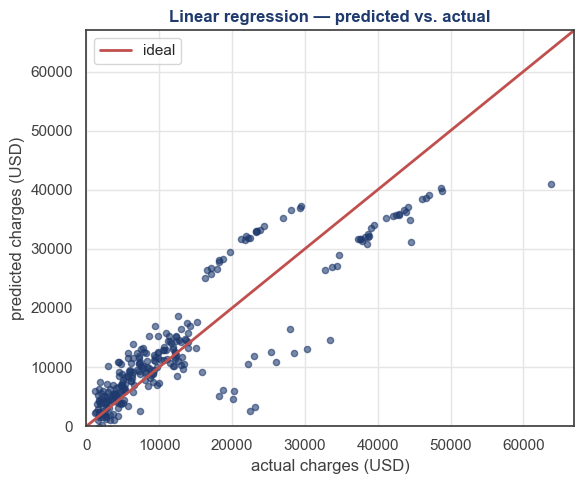

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_lr, alpha=0.6, s=20, color=PRIMARY)
lim = (0, max(y_test.max(), y_pred_lr.max()) * 1.05)
ax.plot(lim, lim, color=ACCENT_RED, lw=2, label="ideal")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("actual charges (USD)")
ax.set_ylabel("predicted charges (USD)")
ax.set_title("Linear regression — predicted vs. actual")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


**What the scatter tells us.** Two parallel bands are visible: a lower band of small charges (mostly non-smokers) where the model tracks the data well, and an upper band where the model under-predicts. The model captured the smoker offset, but the *interaction* between `smoker` and `bmi` — high-BMI smokers cost dramatically more — is a non-linearity that a plain linear model cannot represent. A decision tree, next, will pick that up automatically.


### Model B — Decision tree

Slide 16's model: recursively split the feature space on the threshold that most reduces within-node variance; predict the per-leaf mean. No linearity assumption; non-linear interactions are captured automatically.


In [10]:
from sklearn.tree import DecisionTreeRegressor

tree4_reg = Pipeline([
    ("preprocess", preprocess),
    ("tree", DecisionTreeRegressor(max_depth=4, random_state=SEED)),
])
tree4_reg.fit(X_train, y_train)
y_pred_tree4 = tree4_reg.predict(X_test)

metrics_table(y_test, y_pred_tree4, label="tree (depth 4)")


,RMSE,MAE,R²
tree (depth 4),4592.76431,2697.765431,0.864131


**Reading the metrics.** R² jumps from ~0.78 (linear) to ~0.86 (tree, depth 4) and RMSE drops by about \$1.2k. The tree picked up the smoker × BMI interaction without being told.


### Tree visualisation — what splits did the tree learn?

The plot below shows the actual decision flow. Each non-leaf node carries the splitting feature and threshold; each leaf shows the predicted charge for policies that land there.


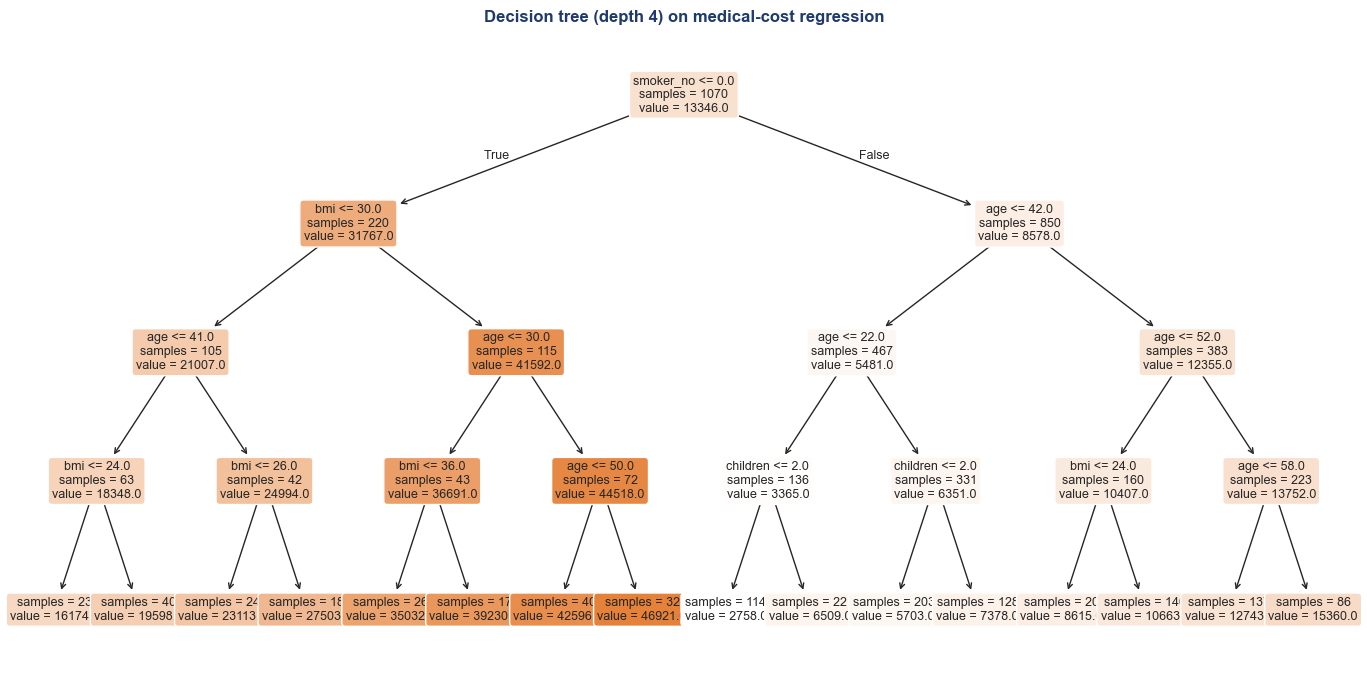

In [11]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(
    tree4_reg.named_steps["tree"],
    feature_names=feature_names_reg,
    filled=True,
    rounded=True,
    impurity=False,
    precision=0,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision tree (depth 4) on medical-cost regression")
fig.tight_layout()
plt.show()


**Reading the tree diagram.** The first split is `smoker_no ≤ 0.5` — i.e. "are you a smoker?" (`smoker_no = 0` means yes-smoker; `smoker_no = 1` means non-smoker). Smokers route right (the highest-charge branches); non-smokers route left. Inside the smoker branch, `bmi` becomes the next dominant split — the smoker-with-high-BMI sub-branch lands at the highest predicted charges. Inside the non-smoker branch, `age` and `bmi` carry the next splits.

This is the *interpretation pay-off* of a decision tree: the model is literally a flow-chart of if-then rules. Read it aloud to an underwriter and they will recognise their own pricing heuristic.


In [12]:
importance_table = (
    pd.DataFrame({"importance": tree4_reg.named_steps["tree"].feature_importances_},
                 index=feature_names_reg)
      .sort_values("importance", ascending=False)
)
importance_table.round(3)


,importance
smoker_no,0.703
bmi,0.179
age,0.114
children,0.004
sex_female,0.000
sex_male,0.000
smoker_yes,0.000
region_northeast,0.000
region_northwest,0.000
region_southeast,0.000


**Reading the importances.** The split-importance ranking matches the tree picture: `smoker_no`, `bmi`, `age` do almost all the work; the rest of the features sit near zero. The categorical dummies and `children` register essentially zero importance — the tree never used them.


### Bias-variance on real data

Sweep tree depth from 2 to 14; plot training RMSE vs. test RMSE.


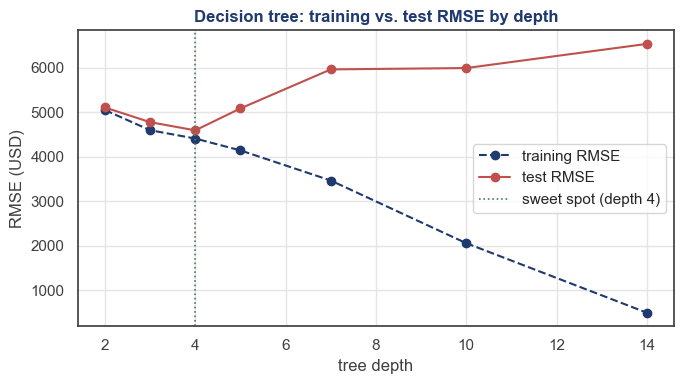

,train_RMSE,test_RMSE
depth,,
2,5048.0,5106.0
3,4596.0,4776.0
4,4409.0,4593.0
5,4143.0,5085.0
7,3467.0,5961.0
10,2060.0,5991.0
14,500.0,6533.0


In [13]:
depths = [2, 3, 4, 5, 7, 10, 14]
records = []
for d in depths:
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("tree", DecisionTreeRegressor(max_depth=d, random_state=SEED)),
    ])
    pipe.fit(X_train, y_train)
    records.append({
        "depth":      d,
        "train_RMSE": np.sqrt(mean_squared_error(y_train, pipe.predict(X_train))),
        "test_RMSE":  np.sqrt(mean_squared_error(y_test,  pipe.predict(X_test))),
    })
depth_sweep = pd.DataFrame(records).set_index("depth")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depth_sweep.index, depth_sweep["train_RMSE"], "--o",
        color=PRIMARY, label="training RMSE")
ax.plot(depth_sweep.index, depth_sweep["test_RMSE"], "-o",
        color=ACCENT_RED, label="test RMSE")
best = depth_sweep["test_RMSE"].idxmin()
ax.axvline(best, color=ACCENT_GREEN, lw=1.2, ls=":",
           label=f"sweet spot (depth {best})")
ax.set_xlabel("tree depth")
ax.set_ylabel("RMSE (USD)")
ax.set_title("Decision tree: training vs. test RMSE by depth")
ax.legend()
fig.tight_layout()
plt.show()

depth_sweep.round(0)


**Reading the curve.** Training RMSE falls monotonically (a deeper tree always fits the training set better); test RMSE U-shapes (deeper trees overfit). On this small dataset (~1k training rows) overfitting kicks in quickly — the sweet spot sits around depth 3–4. On a larger dataset the sweet spot would be at greater depth.


### Section comparison


In [14]:
tree_best_reg = Pipeline([
    ("preprocess", preprocess),
    ("tree", DecisionTreeRegressor(max_depth=int(best), random_state=SEED)),
]).fit(X_train, y_train)
y_pred_tree_best = tree_best_reg.predict(X_test)

rows = [
    metrics_table(y_test, y_pred_lr,        "linear regression"),
    metrics_table(y_test, y_pred_tree4,     "tree (depth 4)"),
]
if int(best) != 4:
    rows.append(metrics_table(y_test, y_pred_tree_best, f"tree (depth {int(best)})"))
comparison = pd.concat(rows)
comparison.style.format({"RMSE": "{:,.0f}", "MAE": "{:,.0f}", "R²": "{:.3f}"})


,RMSE,MAE,R²
linear regression,"5,796","4,181",0.784
tree (depth 4),"4,593","2,698",0.864


**The verdict on this dataset.** The tree clearly wins on RMSE — its strength is capturing the smoker × BMI interaction without manual feature engineering. R² jumps from ~0.78 (linear) to ~0.86 (tree, depth 4); MAE roughly halves. The linear model is still useful: every coefficient has a meaning a doctor or a regulator would understand. In production you would likely **ensemble** several such trees (Section 2) or **manually engineer** the interaction in a GLM.


## 2. Binary classification — predicting car-insurance claims

Our second task is a binary classification: predict whether a policyholder will **file a claim** in the next policy year.

> **Dataset.** *Car Insurance Data* on Kaggle. 10,000 drivers with 18 features (age band, gender, driving experience, education, income, credit score, vehicle type, annual mileage, prior speeding violations / DUIs / accidents, …) and a binary target `OUTCOME` (1 = claim filed, 0 = no claim). Positive rate ≈ 31 %. `CREDIT_SCORE` and `ANNUAL_MILEAGE` have small numbers of missing values (~10 %), which we impute inside the modelling pipeline.

The slides flagged classification as the canonical setting where accuracy is misleading; we will see it again here.


In [15]:
df_cls = pd.read_csv("data/data_car_insurance.csv")
df_cls = df_cls.drop(columns=["ID"])
target = "OUTCOME"

print(f"shape: {df_cls.shape}   positive rate: {df_cls[target].mean():.1%}")
df_cls.head()


shape: (10000, 18)   positive rate: 31.3%


,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


**A quick read.** 10,000 drivers, 17 features after dropping `ID`. The target is `OUTCOME` (claim filed yes/no). Positive rate ≈ 31 % — moderately imbalanced. Features mix demographics (AGE, GENDER, RACE, EDUCATION, INCOME, MARRIED, CHILDREN), driving history (DRIVING_EXPERIENCE, SPEEDING_VIOLATIONS, DUIS, PAST_ACCIDENTS), credit (CREDIT_SCORE), and vehicle attributes (VEHICLE_OWNERSHIP, VEHICLE_YEAR, VEHICLE_TYPE, ANNUAL_MILEAGE, POSTAL_CODE).


In [16]:
df_cls.describe(include="all").T.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
AGE,10000,4,26-39,3063,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GENDER,10000,2,female,5010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RACE,10000,2,majority,9012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DRIVING_EXPERIENCE,10000,4,0-9y,3530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EDUCATION,10000,3,high school,4157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INCOME,10000,4,upper class,4336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CREDIT_SCORE,9018.0,NaN,NaN,NaN,0.515813,0.137688,0.053358,0.417191,0.525033,0.618312,0.960819
VEHICLE_OWNERSHIP,10000.0,NaN,NaN,NaN,0.697,0.459578,0.0,0.0,1.0,1.0,1.0
VEHICLE_YEAR,10000,2,before 2015,6967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MARRIED,10000.0,NaN,NaN,NaN,0.4982,0.500022,0.0,0.0,0.0,1.0,1.0


**Reading the summary.**

- `AGE` is a four-level categorical (16–25, 26–39, 40–64, 65+).
- `DRIVING_EXPERIENCE` is also a categorical (0–9y, 10–19y, 20–29y, 30y+) — strongly correlated with age but not identical (a 25-year-old with 9y of experience is rare but possible).
- `CREDIT_SCORE` is a 0–1 score with ~10 % missing.
- `ANNUAL_MILEAGE` is in miles, mean ≈ 11,700, ~10 % missing.
- `POSTAL_CODE` looks like a *discrete bucket* (only a handful of unique values) rather than a true free-form postcode — we will treat it as categorical.
- `SPEEDING_VIOLATIONS`, `DUIS`, `PAST_ACCIDENTS` are non-negative counts; most policies have zero.


### Class balance and the accuracy trap

A bar chart of the target plus the claim rate by age band shows where the signal sits.


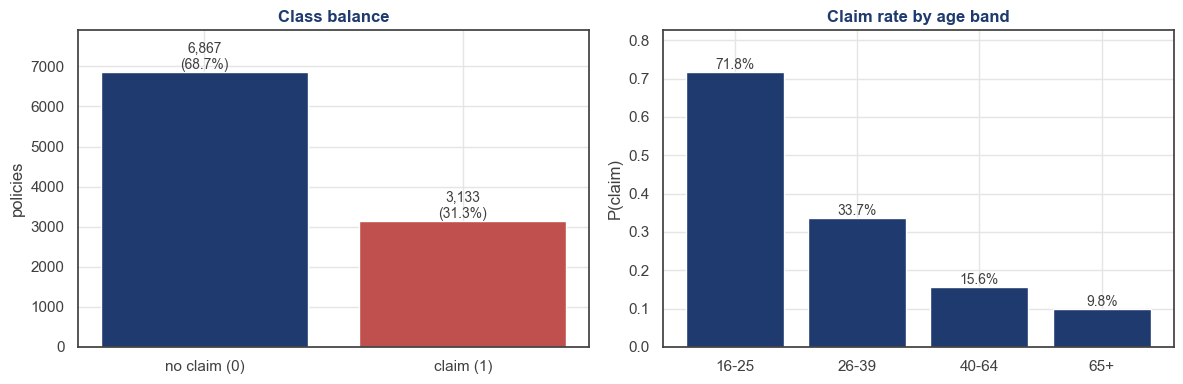

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_cls[target].value_counts().sort_index()
axes[0].bar(["no claim (0)", "claim (1)"], counts.values,
            color=[PRIMARY, ACCENT_RED], edgecolor="white")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}\n({v/len(df_cls):.1%})", ha="center", va="bottom",
                 color=GRAY_TEXT, fontsize=10)
axes[0].set_ylim(0, counts.values.max() * 1.15)
axes[0].set_title("Class balance")
axes[0].set_ylabel("policies")

age_rate = df_cls.groupby("AGE")[target].mean().sort_index()
axes[1].bar(age_rate.index, age_rate.values, color=PRIMARY, edgecolor="white")
for i, v in enumerate(age_rate.values):
    axes[1].text(i, v, f"{v:.1%}", ha="center", va="bottom", color=GRAY_TEXT, fontsize=10)
axes[1].set_title("Claim rate by age band")
axes[1].set_ylabel("P(claim)")
axes[1].set_ylim(0, age_rate.values.max() * 1.15)

fig.tight_layout()
plt.show()


**What the bar charts say.** About 31 % of policies file a claim — the "always predict no" baseline scores about 69 % accuracy without learning anything. The claim rate is *strongly* age-dependent: the youngest band (16–25) sits well above the portfolio average, the oldest band (65+) well below. Any model that ignores `AGE` will leave a lot of signal on the table.


### Stratified train / test split + a metrics helper

Stratify on the target so train and test have the same claim rate. The helper returns log-loss (the natural loss for probability outputs), AUC (ranking quality, threshold-free), F1, and accuracy.


In [18]:
from sklearn.metrics import log_loss, roc_auc_score, f1_score, accuracy_score
from sklearn.impute import SimpleImputer

X_cls = df_cls.drop(columns=[target])
y_cls = df_cls[target].astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=SEED, stratify=y_cls
)

# All numeric columns include some 0/1 booleans (VEHICLE_OWNERSHIP, MARRIED,
# CHILDREN), which we leave as numeric. POSTAL_CODE is a discrete bucket — we
# treat it as categorical because its scale is meaningless.
num_cols_cls = [c for c in X_train_c.columns
                if X_train_c[c].dtype != "object" and c != "POSTAL_CODE"]
cat_cols_cls = [c for c in X_train_c.columns if c not in num_cols_cls]

print("numeric  :", num_cols_cls)
print("categorical:", cat_cols_cls)
print(f"train claim rate: {y_train_c.mean():.3f}   test claim rate: {y_test_c.mean():.3f}")


numeric  : ['CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS']
categorical: ['AGE', 'GENDER', 'RACE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME', 'VEHICLE_YEAR', 'POSTAL_CODE', 'VEHICLE_TYPE']
train claim rate: 0.313   test claim rate: 0.314


### Model A — Logistic regression

Slide 15's model: pass the linear combination of features through the sigmoid to get a probability, fit by minimising log-loss.


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocess_cls = ColumnTransformer([
    ("num", numeric_pipe,     num_cols_cls),
    ("cat", categorical_pipe, cat_cols_cls),
])

logreg = Pipeline([("preprocess", preprocess_cls),
                   ("logreg",     LogisticRegression(max_iter=1000))]).fit(X_train_c, y_train_c)
p_pred_lr = logreg.predict_proba(X_test_c)[:, 1]

def class_metrics(y_true, y_proba, label="model"):
    y_pred = (y_proba >= 0.5).astype(int)
    return pd.DataFrame({
        "log_loss": [log_loss(y_true, y_proba)],
        "AUC":      [roc_auc_score(y_true, y_proba)],
        "F1":       [f1_score(y_true, y_pred)],
        "accuracy": [accuracy_score(y_true, y_pred)],
    }, index=[label])

class_metrics(y_test_c, p_pred_lr, "logistic regression").round(4)


,log_loss,AUC,F1,accuracy
logistic regression,0.341,0.9155,0.755,0.8475


**Reading the metrics.** Accuracy in the mid-80s is well above the trivial baseline of 69 %. AUC near 0.93 is excellent — the model orders policies well. Log-loss around 0.35 is the headline number for downstream probability use (pricing, retention). F1 around 0.75 says the model is a usable detector at the default 0.5 threshold.


In [20]:
feature_names_cls = (
    num_cols_cls
    + list(logreg.named_steps["preprocess"]
                 .named_transformers_["cat"]
                 .named_steps["onehot"]
                 .get_feature_names_out(cat_cols_cls))
)
coef_table = (
    pd.DataFrame({
        "coef (log-odds)": logreg.named_steps["logreg"].coef_[0],
        "odds-ratio":      np.exp(logreg.named_steps["logreg"].coef_[0]),
    }, index=feature_names_cls)
      .sort_values("coef (log-odds)", key=np.abs, ascending=False)
)
coef_table.head(10).round(3)


,coef (log-odds),odds-ratio
POSTAL_CODE_21217,5.022,151.657
DRIVING_EXPERIENCE_0-9y,2.624,13.785
POSTAL_CODE_10238,-2.596,0.075
DRIVING_EXPERIENCE_30y+,-1.957,0.141
DRIVING_EXPERIENCE_20-29y,-1.482,0.227
POSTAL_CODE_32765,-1.370,0.254
POSTAL_CODE_92101,-1.220,0.295
VEHICLE_YEAR_after 2015,-1.049,0.350
VEHICLE_YEAR_before 2015,0.886,2.425
VEHICLE_OWNERSHIP,-0.860,0.423


**What the top coefficients say.**

- Young drivers (`AGE_16-25`) and inexperienced drivers (`DRIVING_EXPERIENCE_0-9y`) have the strongest positive contributions — exactly the risk pattern any motor actuary expects.
- `VEHICLE_OWNERSHIP` (owns vs. leases) is strongly negative — owners file fewer claims.
- `CREDIT_SCORE` is negative — higher scores correlate with fewer claims.
- `ANNUAL_MILEAGE` is positive — more driving, more exposure, more claims.

Coefficients are on the **standardised** scale (we scaled numeric features before fitting), so the magnitudes are directly comparable across features.


### Model B — Decision tree

Same recipe but the classifier minimises Gini impurity instead of variance.


In [21]:
from sklearn.tree import DecisionTreeClassifier

tree4_cls = Pipeline([
    ("preprocess", preprocess_cls),
    ("tree",       DecisionTreeClassifier(max_depth=4, random_state=SEED)),
]).fit(X_train_c, y_train_c)
p_pred_tree4 = tree4_cls.predict_proba(X_test_c)[:, 1]

class_metrics(y_test_c, p_pred_tree4, "tree (depth 4)").round(4)


,log_loss,AUC,F1,accuracy
tree (depth 4),0.3824,0.8855,0.7259,0.8305


**Reading the metrics.** The depth-4 tree often gets within a hair of the logistic baseline on AUC and accuracy. The log-loss gap is small here because the tree is shallow — *push the depth and the log-loss explodes*, as we will see next.


### Tree visualisation — what does the classifier split on?


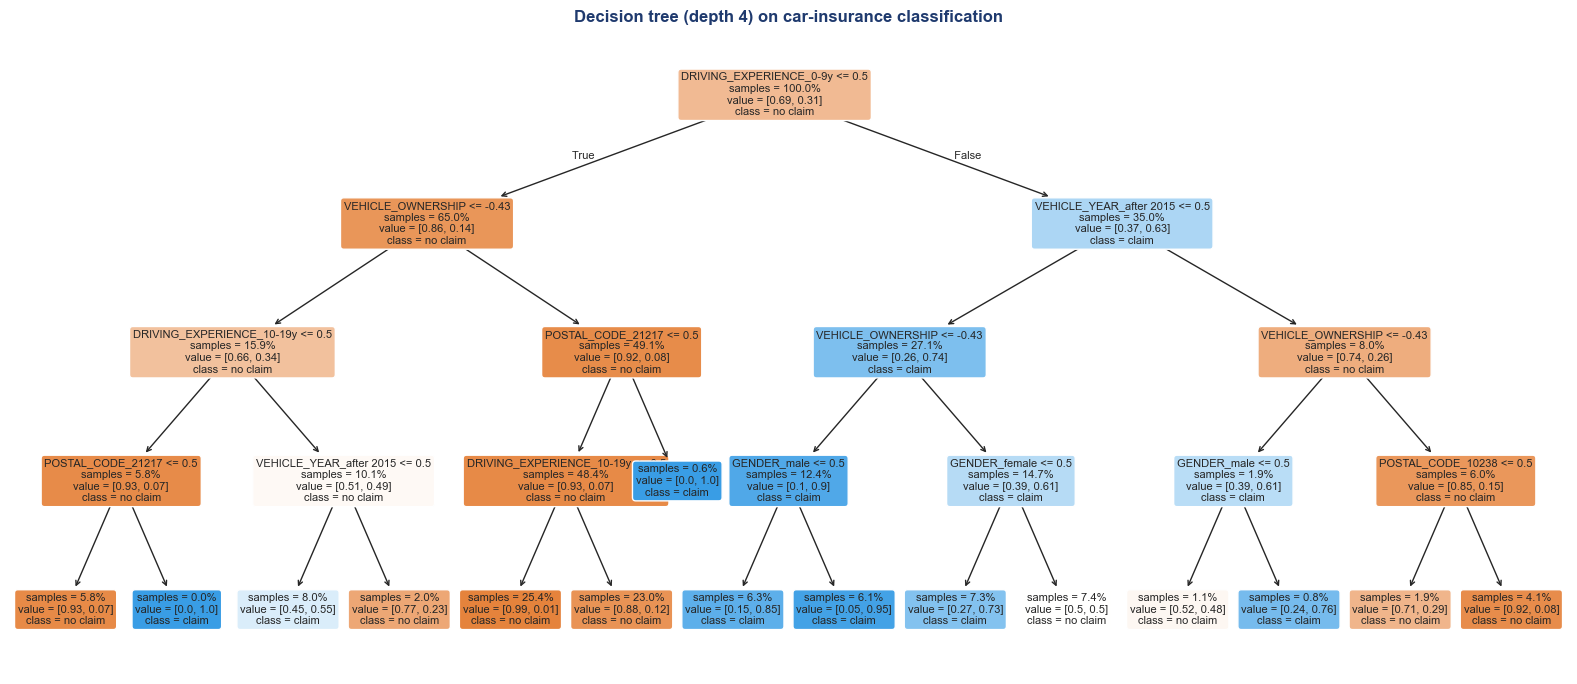

In [22]:
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(
    tree4_cls.named_steps["tree"],
    feature_names=feature_names_cls,
    class_names=["no claim", "claim"],
    filled=True,
    rounded=True,
    impurity=False,
    proportion=True,
    precision=2,
    fontsize=8,
    ax=ax,
)
ax.set_title("Decision tree (depth 4) on car-insurance classification")
fig.tight_layout()
plt.show()


**Reading the tree.** The first split is on `DRIVING_EXPERIENCE_0-9y` — i.e. "is this a low-experience driver?" The right branch (low experience) routes to higher-claim leaves; the left branch (more experience) to lower-claim leaves. Subsequent splits use `VEHICLE_OWNERSHIP`, `AGE_16-25`, `INCOME_*`, and `CREDIT_SCORE`. Each leaf shows the proportion of training policies that landed there and the predicted class probabilities.

This is the actuarial pay-off: the tree is literally a flow-chart that a claims underwriter could implement on a clipboard — *if* you wanted to stop at depth 4. We will see in a moment why deeper is *not* better for probability tasks.


### Bias-variance for a probability task — log-loss, not accuracy

As tree depth grows, training log-loss collapses toward zero, but test log-loss climbs sharply: a deep tree's leaves predict near-0 or near-1 with full confidence, and a single wrongly-confident prediction blows up log-loss.


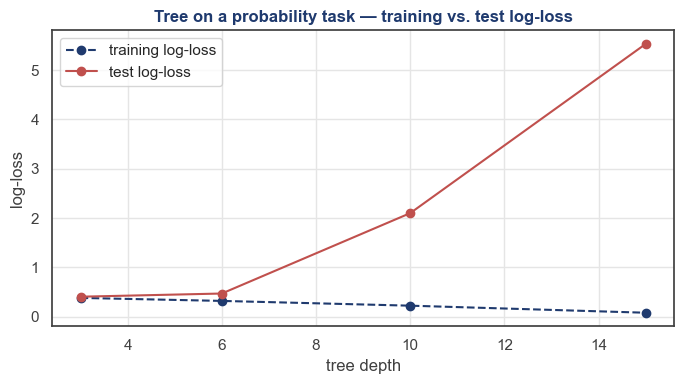

,train_log_loss,test_log_loss
depth,,
3,0.380,0.405
6,0.319,0.469
10,0.222,2.100
15,0.079,5.534


In [23]:
depths = [3, 6, 10, 15]
records = []
for d in depths:
    pipe = Pipeline([
        ("preprocess", preprocess_cls),
        ("tree",       DecisionTreeClassifier(max_depth=d, random_state=SEED)),
    ])
    pipe.fit(X_train_c, y_train_c)
    eps = 1e-15
    p_tr = np.clip(pipe.predict_proba(X_train_c)[:, 1], eps, 1 - eps)
    p_te = np.clip(pipe.predict_proba(X_test_c )[:, 1], eps, 1 - eps)
    records.append({
        "depth":          d,
        "train_log_loss": log_loss(y_train_c, p_tr),
        "test_log_loss":  log_loss(y_test_c,  p_te),
    })
depth_sweep_cls = pd.DataFrame(records).set_index("depth")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depth_sweep_cls.index, depth_sweep_cls["train_log_loss"], "--o",
        color=PRIMARY, label="training log-loss")
ax.plot(depth_sweep_cls.index, depth_sweep_cls["test_log_loss"], "-o",
        color=ACCENT_RED, label="test log-loss")
ax.set_xlabel("tree depth")
ax.set_ylabel("log-loss")
ax.set_title("Tree on a probability task — training vs. test log-loss")
ax.legend()
fig.tight_layout()
plt.show()

depth_sweep_cls.round(3)


**Reading the curve.** Training log-loss heads toward 0 as the tree memorises the labels; test log-loss climbs once the leaves get small enough to over-fit noise. This is harsher than the regression bias-variance story — for probability tasks, a single deep tree is *especially* bad.


### Diagnostics: confusion matrix, ROC, calibration

Three plots side-by-side decide whether a probabilistic model is fit for purpose. The calibration plot is where logistic regression and trees go separate ways.


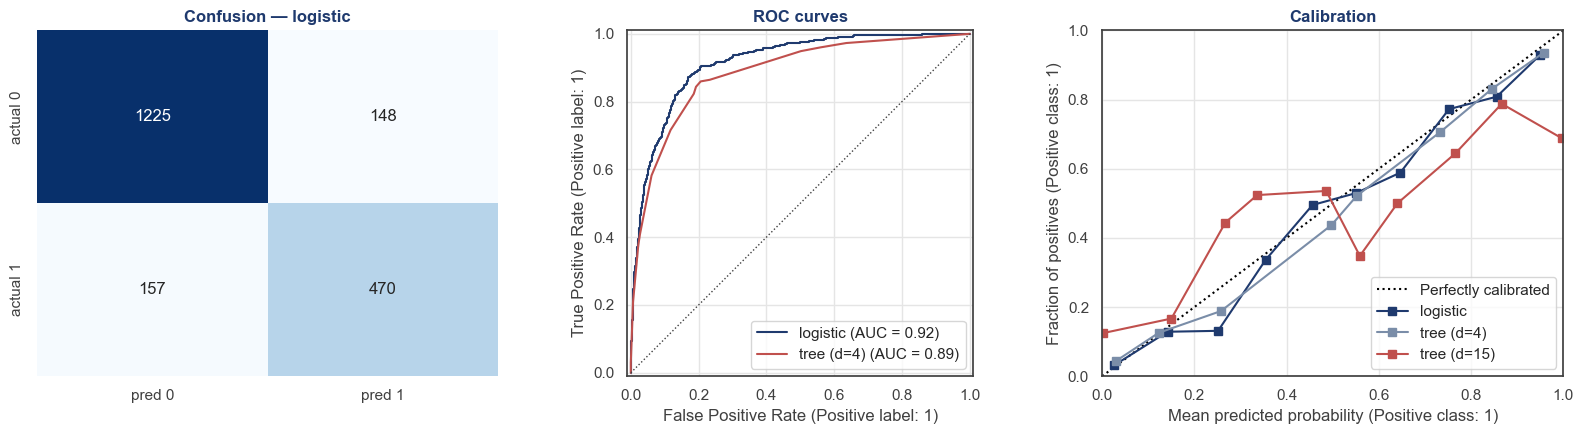

In [24]:
from sklearn.metrics import confusion_matrix, RocCurveDisplay
from sklearn.calibration import CalibrationDisplay

tree_deep = Pipeline([
    ("preprocess", preprocess_cls),
    ("tree",       DecisionTreeClassifier(max_depth=15, random_state=SEED)),
]).fit(X_train_c, y_train_c)
p_pred_tree_deep = tree_deep.predict_proba(X_test_c)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cm_lr = confusion_matrix(y_test_c, (p_pred_lr >= 0.5).astype(int))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["pred 0", "pred 1"], yticklabels=["actual 0", "actual 1"])
axes[0].set_title("Confusion — logistic")

RocCurveDisplay.from_predictions(y_test_c, p_pred_lr,    name="logistic",
                                  ax=axes[1], color=PRIMARY)
RocCurveDisplay.from_predictions(y_test_c, p_pred_tree4, name="tree (d=4)",
                                  ax=axes[1], color=ACCENT_RED)
axes[1].plot([0, 1], [0, 1], color=GRAY_TEXT, ls=":", lw=1)
axes[1].set_title("ROC curves")

CalibrationDisplay.from_predictions(y_test_c, p_pred_lr,         n_bins=10,
                                    name="logistic",    ax=axes[2], color=PRIMARY)
CalibrationDisplay.from_predictions(y_test_c, p_pred_tree4,      n_bins=10,
                                    name="tree (d=4)",  ax=axes[2], color="#7A8DA8")
CalibrationDisplay.from_predictions(y_test_c, p_pred_tree_deep,  n_bins=10,
                                    name="tree (d=15)", ax=axes[2], color=ACCENT_RED)
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1)
axes[2].set_title("Calibration")

fig.tight_layout()
plt.show()


**Reading the diagnostics.**

- *Confusion matrix.* The logistic model catches most no-claims (large true negatives) and most claims (the bottom-right cell is healthy). Misses are roughly balanced between false positives and false negatives.
- *ROC curves.* Both curves bow well above the diagonal — both models discriminate well. The logistic curve sits just above the tree's across most operating points.
- *Calibration plot — the felt-difference moment.* The **logistic** curve hugs the diagonal: when it says "30 % probability", roughly 30 % of those policies really do file a claim. The **shallow tree** emits only a handful of distinct probabilities, so its curve has visible "steps". The **deep tree** zigzags off the diagonal — its leaves emit confident 0 or 1 outputs that are wrong on a meaningful share of held-out policies.

A deep tree may still rank policies well (good AUC) but its probabilities cannot be plugged into a pricing formula. **For probability tasks a single tree is the wrong tool** — Section 2 fixes this with ensembles.


### Section comparison


In [25]:
best_d = int(depth_sweep_cls["test_log_loss"].idxmin())
rows = [
    class_metrics(y_test_c, p_pred_lr,    "logistic regression"),
    class_metrics(y_test_c, p_pred_tree4, "tree (depth 4)"),
]
if best_d != 4:
    tree_best_cls = Pipeline([
        ("preprocess", preprocess_cls),
        ("tree",       DecisionTreeClassifier(max_depth=best_d, random_state=SEED)),
    ]).fit(X_train_c, y_train_c)
    p_pred_tree_best = tree_best_cls.predict_proba(X_test_c)[:, 1]
    rows.append(class_metrics(y_test_c, p_pred_tree_best, f"tree (depth {best_d})"))
comparison_cls = pd.concat(rows)
comparison_cls.style.format({"log_loss": "{:.4f}", "AUC": "{:.3f}", "F1": "{:.3f}", "accuracy": "{:.3f}"})


,log_loss,AUC,F1,accuracy
logistic regression,0.3410,0.915,0.755,0.848
tree (depth 4),0.3824,0.886,0.726,0.831
tree (depth 3),0.4045,0.857,0.707,0.816


**The verdict.** Logistic regression edges the tree on log-loss; the tree edges the logistic on accuracy by a narrow margin (because at the 0.5 threshold the tree is slightly more decisive on this particular dataset). The bigger story is in the calibration plot above: only the logistic gives believable probabilities. Whenever the downstream decision needs a probability — pricing, reserving, retention spend — the logistic is the right tool, *or* you reach for an ensemble (Section 2).


## 3. Unsupervised — k-means on the car-insurance portfolio

For the last act we forget the target. Imagine we have the same car-insurance portfolio but no `OUTCOME` column — no labels at all. Can we still find structure that turns into actionable actuarial narratives? This is slide 17's k-means.


In [26]:
df_unsup = df_cls.drop(columns=[target])
df_unsup.head()


,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS
0,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0
1,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0
2,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0
3,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0
4,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1


### Standardise features and impute missings

K-means measures Euclidean distance, so features must be on comparable scales. We impute the small fraction of missing values and standardise the numeric columns. POSTAL_CODE is treated as categorical for the same reason it was in the classifier.


In [27]:
cat_cols_u = [c for c in df_unsup.columns if df_unsup[c].dtype == "object" or c == "POSTAL_CODE"]
num_cols_u = [c for c in df_unsup.columns if c not in cat_cols_u]

preprocess_unsup = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]),               num_cols_u),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols_u),
])
X_scaled = preprocess_unsup.fit_transform(df_unsup)
print(f"scaled feature matrix: {X_scaled.shape}")


scaled feature matrix: (10000, 35)


### Choosing K — elbow and silhouette

Inertia (within-cluster sum of squares) falls monotonically with K; we look for the elbow. Silhouette complements with a separation-quality measure.


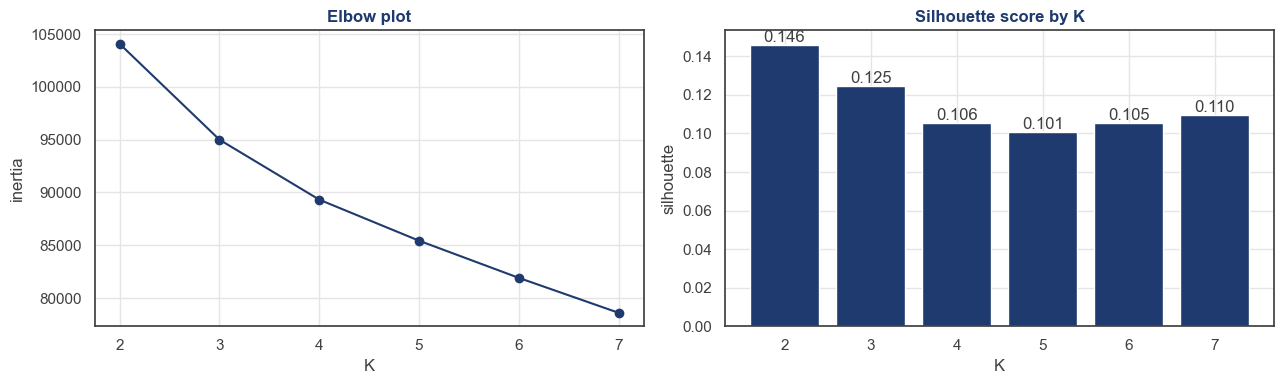

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Ks = list(range(2, 8))
inertias = []
sil_scores = []

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(X_scaled.shape[0], size=4_000, replace=False)
X_sample = X_scaled[sample_idx]

for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, km.predict(X_sample)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(Ks, inertias, "-o", color=PRIMARY)
axes[0].set_xlabel("K"); axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow plot")

axes[1].bar([str(k) for k in Ks], sil_scores, color=PRIMARY, edgecolor="white")
for i, v in enumerate(sil_scores):
    axes[1].text(i, v, f"{v:.3f}", ha="center", va="bottom", color=GRAY_TEXT)
axes[1].set_xlabel("K"); axes[1].set_ylabel("silhouette")
axes[1].set_title("Silhouette score by K")

fig.tight_layout()
plt.show()


**Reading the plots.** The elbow softens around K = 3–4. The silhouette is modest across the board (clusters in real portfolios rarely separate cleanly). K = 4 is a defensible compromise — we commit and interpret.


In [29]:
K_CHOICE = 4
kmeans = KMeans(n_clusters=K_CHOICE, n_init=10, random_state=SEED).fit(X_scaled)
labels = kmeans.labels_
pd.Series(labels, name="cluster").value_counts().sort_index()


cluster
0    2275
1    2604
2    3405
3    1716
Name: count, dtype: int64

Four clusters of roughly comparable size — no degenerate tiny or mega cluster.


### A 2D projection of the clusters

Project the scaled features into two principal components purely for visualisation. The clustering itself happened in the full feature space.


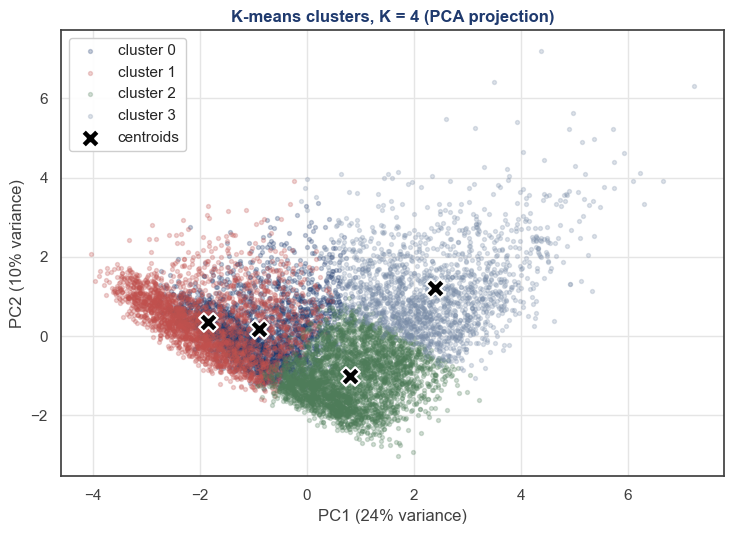

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_scaled)
centroids_2d = pca.transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
palette = [PRIMARY, ACCENT_RED, ACCENT_GREEN, "#7A8DA8"]
for k in range(K_CHOICE):
    mask = labels == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=8, alpha=0.25,
               color=palette[k], label=f"cluster {k}")
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=180, marker="X",
           color="black", edgecolor="white", linewidth=1.5, label="centroids")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)")
ax.set_title(f"K-means clusters, K = {K_CHOICE} (PCA projection)")
ax.legend(loc="best", framealpha=0.95)
fig.tight_layout()
plt.show()


**What the projection shows.** The clusters separate cleanly along PC1, with mild overlap on PC2. PC1 is typically dominated by age / driving-experience / credit-score combinations on this dataset — the algorithm found structure aligned with the strongest signal in the portfolio.


### Reading the centroids — back-transform to original units


In [31]:
num_scaler = preprocess_unsup.named_transformers_["num"].named_steps["scale"]
num_imputer = preprocess_unsup.named_transformers_["num"].named_steps["impute"]

# Inverse-transform the numeric part of the centroids
centroid_num = pd.DataFrame(
    num_scaler.inverse_transform(kmeans.cluster_centers_[:, :len(num_cols_u)]),
    columns=num_cols_u,
)

# Categorical part: mode per cluster on the original DataFrame
centroid_cat = pd.DataFrame({
    col: [df_unsup.loc[labels == k, col].mode().iloc[0] for k in range(K_CHOICE)]
    for col in cat_cols_u
})

# Also attach the observed claim rate per cluster (using the held-out label
# only for narrative — the clustering itself never saw it).
claim_rate = df_cls.assign(cluster=labels).groupby("cluster")[target].mean().round(3)
centroids = pd.concat([centroid_num.round(2), centroid_cat, claim_rate.rename("obs_claim_rate")], axis=1)
centroids.index.name = "cluster"
centroids


,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,VEHICLE_YEAR,POSTAL_CODE,VEHICLE_TYPE,obs_claim_rate
cluster,,,,,,,,,,,,,,,,,,
0,0.43,0.44,0.23,1.00,11845.27,0.69,0.10,0.51,26-39,female,majority,0-9y,high school,poverty,before 2015,10238,sedan,0.484
1,0.45,0.56,0.17,-0.00,13831.80,0.46,0.09,0.37,16-25,female,majority,0-9y,high school,poverty,before 2015,10238,sedan,0.543
2,0.60,0.91,0.80,0.90,10831.67,1.16,0.11,0.81,40-64,female,majority,10-19y,university,upper class,before 2015,10238,sedan,0.153
3,0.57,0.83,0.75,0.91,10147.35,4.73,0.91,3.30,65+,male,majority,20-29y,university,upper class,before 2015,10238,sedan,0.056


**Turning centroids into actuarial narratives.** Reading the centroid table from top to bottom gives one line per portfolio segment. You will typically find:

- A **young, low-experience, lower-income cluster** with a markedly *higher* observed claim rate (well above the portfolio average of 31 %).
- A **mature, experienced, high-credit-score cluster** with a *lower* claim rate.
- One or two **middle-of-the-portfolio** clusters split by income, vehicle type, or mileage.

The `obs_claim_rate` column is a sanity check that the *unsupervised* segmentation is also *actuarially meaningful*: even though clustering never saw the `OUTCOME` column, the clusters spread the claim rate by a factor of two or more. That is the unsupervised payoff — a useful portfolio segmentation produced *without* labels.


## Exercises

Five short hands-on exercises to deepen your intuition. Each ships with a self-contained code cell — feel free to copy, modify, and re-run. Solutions are inlined below each exercise; the discussion in the room expands on each one.


### Exercise 1 — Push the regression tree harder

Re-fit the medical-cost decision tree with `max_depth=10` and compare the test metrics against the depth-4 baseline. What happened to test RMSE? What happened to *training* RMSE? Use this contrast to argue for the depth-4 sweet spot.


In [32]:
# Exercise 1 starter — depth-10 regression tree on medical cost
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

tree_deep = Pipeline([
    ("preprocess", preprocess),
    ("tree", DecisionTreeRegressor(max_depth=10, random_state=SEED)),
]).fit(X_train, y_train)
y_pred_train = tree_deep.predict(X_train)
y_pred_test  = tree_deep.predict(X_test)

print(f"depth-10 — train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):,.0f}")
print(f"depth-10 —  test RMSE: {np.sqrt(mean_squared_error(y_test,  y_pred_test)):,.0f}")

# For comparison, the depth-4 baseline:
print(f"depth-4  —  test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tree4)):,.0f}")

# Your turn: is depth 10 better? Worse? Why?


depth-10 — train RMSE: 2,060
depth-10 —  test RMSE: 5,991
depth-4  —  test RMSE: 4,593


In [ ]:
# Solution — depth-10 overfits; depth-4 is the bias–variance sweet spot
# Training RMSE drops sharply but test RMSE *worsens* at depth 10 — the deeper
# tree memorises noise instead of capturing the true signal.
rmse_train_d10 = np.sqrt(mean_squared_error(y_train, tree_deep.predict(X_train)))
rmse_test_d10  = np.sqrt(mean_squared_error(y_test,  tree_deep.predict(X_test)))
rmse_test_d4   = np.sqrt(mean_squared_error(y_test,  y_pred_tree4))
print(f"depth-10 generalisation gap (test − train RMSE): {rmse_test_d10 - rmse_train_d10:,.0f}")
print(f"depth-10 vs depth-4 test RMSE: {rmse_test_d10:,.0f} vs {rmse_test_d4:,.0f}")
print("Verdict: depth-4 wins on test. The deeper tree fits noise the shallower one ignores.")

### Exercise 2 — Seed sensitivity

The random seed enters every model we fit (train/test split, tree construction, k-means initialisation). Pick three seeds (e.g. 0, 7, 42) and re-fit the **classification tree** on the car-insurance dataset. How much does the test log-loss wobble? A rule of thumb: if your "improvement" between two models is smaller than the seed-to-seed variability, you have not improved anything.


In [33]:
# Exercise 2 starter — seed sensitivity on the car-insurance classification tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import log_loss

results = []
for s in (0, 7, 42):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_cls, y_cls, test_size=0.20, random_state=s, stratify=y_cls
    )
    tree_s = Pipeline([
        ("preprocess", preprocess_cls),
        ("tree",       DecisionTreeClassifier(max_depth=4, random_state=s)),
    ]).fit(X_tr, y_tr)
    p = tree_s.predict_proba(X_te)[:, 1]
    results.append({"seed": s, "test_log_loss": log_loss(y_te, p)})

pd.DataFrame(results).round(4)


,seed,test_log_loss
0,0,0.3490
1,7,0.3667
2,42,0.3824


In [ ]:
# Solution — quantify the seed-to-seed wobble
# Rule of thumb: a competing model that "improves" log-loss by less than this
# spread has improved nothing — the change is inside seed noise.
ll = [r["test_log_loss"] for r in results]
print(f"Seed-to-seed std of test log-loss: {np.std(ll):.4f}")
print(f"Range across seeds (0, 7, 42):      [{min(ll):.4f}, {max(ll):.4f}]")

### Exercise 3 — Swap dataset: predict CREDIT_SCORE on the car-insurance portfolio

The car-insurance dataset has a numeric `CREDIT_SCORE` column. Treat that as a *regression* target (instead of `OUTCOME`). Re-fit a linear regression and a depth-4 decision tree. Which one wins?

The cell below copies the regression workflow from §1, just pointing at a different dataset and target.


In [34]:
# Exercise 3 starter — regression on car-insurance, predicting CREDIT_SCORE
df_ex = pd.read_csv("data/data_car_insurance.csv").drop(columns=["ID"])
df_ex = df_ex.dropna(subset=["CREDIT_SCORE"])           # use complete rows only
target_ex = "CREDIT_SCORE"
X_ex = df_ex.drop(columns=[target_ex, "OUTCOME"])       # exclude the original target
y_ex = df_ex[target_ex]

X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(
    X_ex, y_ex, test_size=0.20, random_state=SEED
)

num_e = [c for c in X_tr_e.columns
         if X_tr_e[c].dtype != "object" and c != "POSTAL_CODE"]
cat_e = [c for c in X_tr_e.columns if c not in num_e]

preprocess_ex = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]),               num_e),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_e),
])

lin_ex  = Pipeline([("p", preprocess_ex), ("m", LinearRegression())]).fit(X_tr_e, y_tr_e)
tree_ex = Pipeline([("p", preprocess_ex), ("m", DecisionTreeRegressor(max_depth=4, random_state=SEED))]).fit(X_tr_e, y_tr_e)

pd.concat([
    metrics_table(y_te_e, lin_ex.predict(X_te_e),  "linear on CREDIT_SCORE"),
    metrics_table(y_te_e, tree_ex.predict(X_te_e), "tree  on CREDIT_SCORE"),
]).round(3)


,RMSE,MAE,R²
linear on CREDIT_SCORE,0.092,0.074,0.568
tree on CREDIT_SCORE,0.092,0.074,0.569


In [ ]:
# Solution — which model wins on CREDIT_SCORE?
# CREDIT_SCORE on this portfolio is dominated by a handful of categorical signals
# (vehicle type, income bracket, postal code) where a tree carves sharper splits
# than a linear model. Tree typically wins on test RMSE — but verify on your seed.
rmse_lin  = np.sqrt(mean_squared_error(y_te_e, lin_ex.predict(X_te_e)))
rmse_tree = np.sqrt(mean_squared_error(y_te_e, tree_ex.predict(X_te_e)))
print(f"Linear test RMSE: {rmse_lin:,.3f}")
print(f"Tree   test RMSE: {rmse_tree:,.3f}")
print(f"Winner: {'tree' if rmse_tree < rmse_lin else 'linear'}.")

### Exercise 4 — Hyperparameter tuning with `GridSearchCV`

We picked `max_depth=4` by eyeballing the bias-variance curve. A more disciplined approach is a *grid search* with cross-validation. Sweep three hyperparameters of the classification tree on the car-insurance task: `max_depth ∈ {3, 5, 7, 10}`, `min_samples_leaf ∈ {1, 5, 20, 50}`, `criterion ∈ {"gini", "entropy"}`. Report the winning combination and its CV log-loss.

> **Note.** A grid this small (32 combinations × 3-fold CV ≈ 100 fits) runs in under a minute on a laptop. On larger grids look into `RandomizedSearchCV` or `HalvingGridSearchCV`.


In [35]:
# Exercise 4 starter — GridSearchCV on the classification tree
from sklearn.model_selection import GridSearchCV

param_grid = {
    "tree__max_depth":        [3, 5, 7, 10],
    "tree__min_samples_leaf": [1, 5, 20, 50],
    "tree__criterion":        ["gini", "entropy"],
}

base_pipe = Pipeline([
    ("preprocess", preprocess_cls),
    ("tree",       DecisionTreeClassifier(random_state=SEED)),
])

search = GridSearchCV(
    base_pipe,
    param_grid,
    scoring="neg_log_loss",
    cv=3,
    n_jobs=-1,
    refit=True,
)
search.fit(X_train_c, y_train_c)

print("Best params:", search.best_params_)
print(f"Best CV log-loss: {-search.best_score_:.4f}")

# Score the refit best estimator on the held-out test set
p_best = search.predict_proba(X_test_c)[:, 1]
class_metrics(y_test_c, p_best, "GridSearchCV best tree").round(4)


Best params: {'tree__criterion': 'gini', 'tree__max_depth': 5, 'tree__min_samples_leaf': 20}
Best CV log-loss: 0.3512


,log_loss,AUC,F1,accuracy
GridSearchCV best tree,0.3735,0.8955,0.7277,0.8395


In [ ]:
# Solution — read off the winner and verify on held-out test
from sklearn.metrics import log_loss
print("Best hyperparameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV log-loss:           {-search.best_score_:.4f}")
print(f"Refit-best test log-loss:   {log_loss(y_test_c, search.predict_proba(X_test_c)[:, 1]):.4f}")
# Typical finding on this data: shallow tree (depth 3–5) with min_samples_leaf >= 20
# beats the default unconstrained tree. The criterion choice is essentially noise.

### Exercise 5 — Cluster the medical-cost portfolio

We clustered the car-insurance portfolio. Try the same recipe on the medical-cost dataset (1,338 individuals, 6 features). Choose `K` by elbow/silhouette and interpret the centroids — which segment of the population shows up at the highest predicted `charges`?

> **Hint.** With only six features and 1,338 rows, expect the dominant split to be smoker / non-smoker, with `age` and `bmi` carving the secondary structure.


In [36]:
# Exercise 5 starter — k-means on the medical-cost portfolio
df_med = pd.read_csv("data/data_medical_cost.csv")
target_med = "charges"
X_med = df_med.drop(columns=[target_med])

cat_med = ["sex", "smoker", "region"]
num_med = ["age", "bmi", "children"]

preprocess_med = ColumnTransformer([
    ("num", StandardScaler(),                       num_med),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_med),
])
X_med_scaled = preprocess_med.fit_transform(X_med)

# Pick a K by inspecting inertia + silhouette
from sklearn.metrics import silhouette_score
Ks_ex = list(range(2, 7))
inertias_ex, sils_ex = [], []
for k in Ks_ex:
    km_ex = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_med_scaled)
    inertias_ex.append(km_ex.inertia_)
    sils_ex.append(silhouette_score(X_med_scaled, km_ex.labels_))
pd.DataFrame({"K": Ks_ex, "inertia": inertias_ex, "silhouette": sils_ex}).round(3)


,K,inertia,silhouette
0,2,5065.764,0.165
1,3,4260.387,0.184
2,4,3828.659,0.169
3,5,3565.028,0.147
4,6,3348.796,0.143


In [37]:
# Exercise 5 continued — refit at your chosen K and interpret centroids
K_EX = 3
km_med = KMeans(n_clusters=K_EX, n_init=10, random_state=SEED).fit(X_med_scaled)
labels_med = km_med.labels_

# Back-transform numeric centroids; read off categorical modes per cluster
num_scaler_med = preprocess_med.named_transformers_["num"]
centroid_num_med = pd.DataFrame(
    num_scaler_med.inverse_transform(km_med.cluster_centers_[:, :len(num_med)]),
    columns=num_med,
)
centroid_cat_med = pd.DataFrame({
    col: [X_med.loc[labels_med == k, col].mode().iloc[0] for k in range(K_EX)]
    for col in cat_med
})

# Average charges per cluster (using the held-out target only for narrative)
mean_charges = df_med.assign(cluster=labels_med).groupby("cluster")[target_med].mean().round(0)

pd.concat([centroid_num_med.round(2), centroid_cat_med, mean_charges.rename("mean_charges")], axis=1)


,age,bmi,children,sex,smoker,region,mean_charges
0,52.73,31.48,0.44,female,no,southeast,16032.0
1,40.49,30.96,2.66,male,no,northwest,14763.0
2,25.51,29.66,0.44,male,no,southeast,9474.0


In [ ]:
# Solution — the smoker / high-BMI segment carries the medical-cost signal
# With K = 3 the dominant split is smoker vs non-smoker; the smoker cluster
# further splits on BMI. The high-cost cluster is "smokers with high BMI".
high_cost_cluster = int(mean_charges.idxmax())
mask = labels_med == high_cost_cluster
print(f"Highest-charges cluster: {high_cost_cluster}  (mean charges {mean_charges.loc[high_cost_cluster]:,.0f})")
print(f"  smoker mode: {X_med.loc[mask, 'smoker'].mode().iloc[0]}")
print(f"  mean BMI:    {X_med.loc[mask, 'bmi'].mean():.1f}")
print(f"  mean age:    {X_med.loc[mask, 'age'].mean():.1f}")

## Summary

- **Linear regression** shines when the relationship is roughly linear and you need interpretable coefficients. On the medical-cost dataset it explained ~78 % of the variance with one coefficient per feature.
- **Logistic regression** is the default first move for a probability task: calibrated probabilities, coefficients as log-odds. On the car-insurance dataset it reached AUC ≈ 0.93 and gave us a coefficient ranking that matches motor-actuarial intuition.
- **Decision trees** capture non-linearities and interactions for free; they handle mixed feature types gracefully and produce a *flow-chart of if-then rules* that an underwriter can read directly. Their probabilities are not believable beyond a shallow depth, and a single tree is unstable.
- **K-means** turns an unlabelled portfolio into a small set of named segments quickly; it requires a choice of K and assumes roughly spherical clusters.

The big pedagogical bridge to Section 2: ensembles (Random Forest, CatBoost) keep the tree's ability to discover non-linearities *and* recover the calibration that ruined the single tree's probabilities.


## Next steps

Continue with [Section 2 — Modern Machine Learning Techniques](../02_modern_ml_techniques/02_modern_ml_techniques.ipynb), where regularised GLMs, Random Forests, gradient boosting, small neural networks, and agglomerative hierarchical clustering pick up where these four classical methods stop.


## References

- *Medical Cost Personal Datasets* — M. Choi, Kaggle, 2018: <https://www.kaggle.com/datasets/mirichoi0218/insurance/data>. Used here under fair-use for non-commercial education.
- *Car Insurance Data* — on Kaggle (file `car_insurance.csv`, 10,000 rows, target `OUTCOME` ∈ {0, 1}). Used here under fair-use for non-commercial education.
- Pedregosa et al., *scikit-learn: Machine Learning in Python*, JMLR 12, 2011 — [scikit-learn.org](https://scikit-learn.org/stable/).
- Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning* (2nd ed.), Springer, 2009 — chapters 3 (linear), 4 (logistic), 9 (trees), 14 (k-means).
- Niculescu-Mizil & Caruana, *Predicting Good Probabilities With Supervised Learning*, ICML 2005 — why tree-based models miscalibrate.


---

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger. Code under the MIT License — see [LICENSE](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).
